### [문제] 야후 파이낸스에서 관심 있는 종목을 하나 선택한 다음 마지막 1년치 데이터를 예측해서 정확도를 구한 후 출력하고 시각화한 결과를 보여주는 코드를 작성하시오.

제출형식: 홍길동_0526_티커_mae.ipynb

<처리조건>  
1. 정확도는 MAE를 사용한다.
2. 마지막에 실제값과 예측 값을 동시에 라인차트로 출력한다.
3. 그리고 기존 데이터를 시각화한 다음 이후에 예측한 결과를 시각화 하는 부분도 추가로 표현한다.
4. 최소한 데이터는 5년 이상을 기준으로 학습한다.
5. 기준은 종가 데이터를 사용한다.
6. 그리고 데이터에 대하여 계절성 유무라던지 필요한 분석 내용도 포함한다.
7. 모델은 Prophat을 사용한다.

In [1]:
import pandas as pd
import yfinance as yf
from prophet import Prophet
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

# 데이터 로드
df = yf.download('^GSPC', start='2019-01-01', end='2025-12-31', progress=False)
# print(df.head())
print('================================================================================')
print(df.columns) # 구조확

# 전처리
df.columns = df.columns.get_level_values(0) # 멀티인덱스 중 0번째 증인 값만 가져온다
df = df.reset_index()                       # 인덱스 역할을 하던 날짜를 일반 index로 변환
df = df.rename(columns={'index': 'ds', 'Close': 'y'}) # 'index'가 Date를 가리킴
df = df[['ds', 'y']]                        # ds, y 만 남겨둠
print(df.head())

Importing plotly failed. Interactive plots will not work.


MultiIndex([( 'Close', '^GSPC'),
            (  'High', '^GSPC'),
            (   'Low', '^GSPC'),
            (  'Open', '^GSPC'),
            ('Volume', '^GSPC')],
           names=['Price', 'Ticker'])
Price         ds            y
0     2019-01-02  2510.030029
1     2019-01-03  2447.889893
2     2019-01-04  2531.939941
3     2019-01-07  2549.689941
4     2019-01-08  2574.409912


In [2]:
# 위의 S&P500의 데이터를 head() & columns로 확인해보니 다중 인덱스 (Multi-Index)구조이다.
# 이후에 사용되는 라이브러리에 사용할 수 있도록 복잡한 구조에서 평탄화 작업을 해줘야한다.

In [3]:
# 데이터 분리 # 주말 제외
train = df.iloc[:-252]
test = df.iloc[-252:]
y_true = test['y'].values

# 모델 생성 및 학습
model = Prophet()
model.fit(train)

# 예측 수행
future = model.make_future_dataframe(periods=252)
forecast = model.predict(future)
y_pred = forecast['yhat'].iloc[-252:].values

# MAE 결과 출력
mae = mean_absolute_error(y_true, y_pred)
print('MAE: %.3f' % mae)

17:24:56 - cmdstanpy - INFO - Chain [1] start processing
17:24:56 - cmdstanpy - INFO - Chain [1] done processing


MAE: 342.253


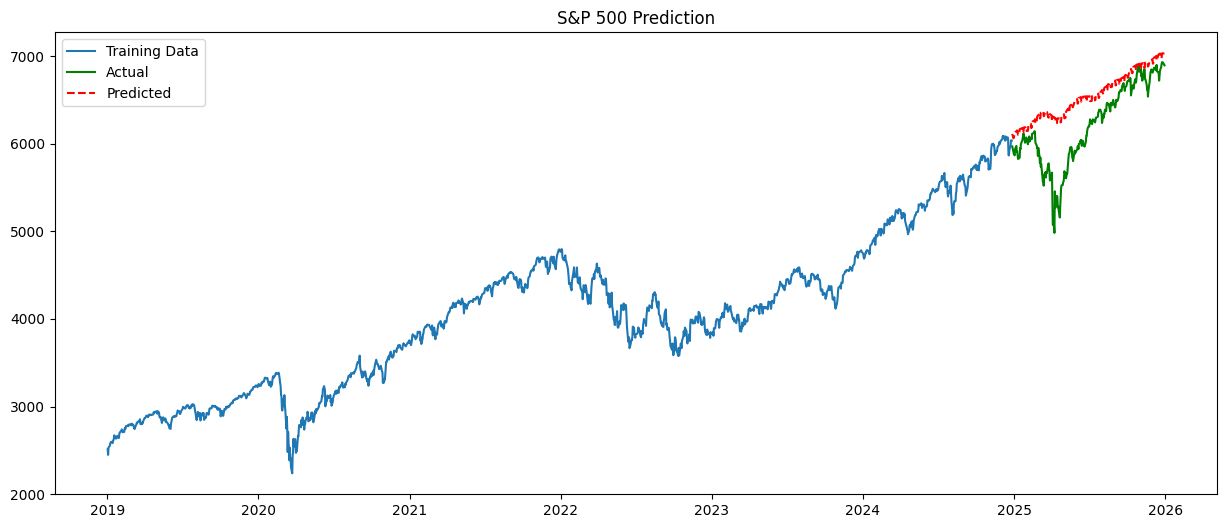

In [4]:
# 시각화 (기존 데이터와 예측값 비교)
plt.figure(figsize=(15, 6))
plt.plot(train['ds'], train['y'], label='Training Data')
plt.plot(test['ds'], y_true, label='Actual', color='green')
plt.plot(test['ds'], y_pred, label='Predicted', color='red', linestyle='--')
plt.legend()
plt.title('S&P 500 Prediction')
plt.show()

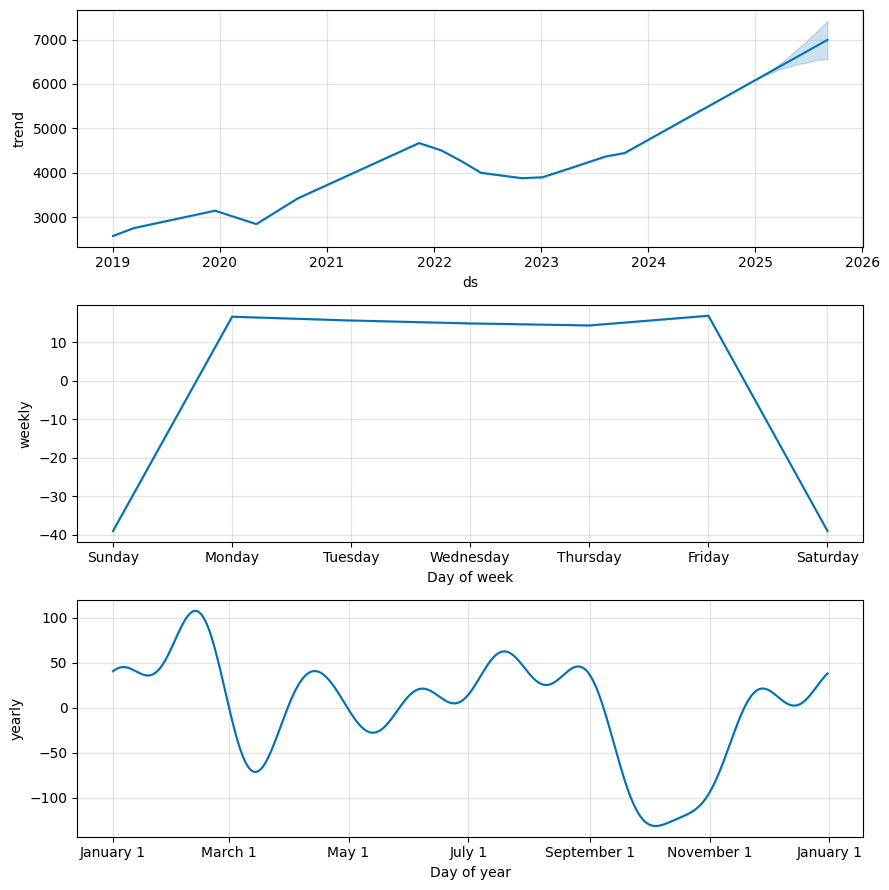

In [5]:
#계절성 분석
model.plot_components(forecast)
plt.show()

In [6]:
# 기업 회계연도 마감 영향: 미국 연방정부의 회계연도가 10월에 시작되기 때문에, 9월에 예산 마감 및 자금 회수가 집중되어 시장의 유동성이 일시적으로 줄어들 수 있습니다.
# 펀드 매니저의 포트폴리오 조정: 3분기 말(9월)과 4분기를 앞두고 펀드 매니저들이 수익률을 확정 짓거나 위험 자산을 줄이는 리밸런싱을 진행합니다
